### Combination of Event PDFs from Multiple Trench Sites ###

***The Weighted-Mean Method***

At this stage, we have defined n events based on the correlation between multiple PDFs. Each event is supported by the agreement of two or more PDFs from neighboring trench sites.

In this notebook, we apply the <i>weighted-mean method</i> to combine the correlated PDFs from multiple sites in order to derive a single paleoearthquake time series representative of the entire fault system, or of the specific spatial scale under consideration.



In [4]:
import numpy as np
import matplotlib.pyplot as plt
#from scipy.integrate import simps
import pandas as pd
from pathlib import Path

---------------------------------------------------------------------------------------------------------------------------------------------
***Loading Data***\
Here we load a txt file with the full set of paleoevents documented from the all the trench sites in consideration. 
The file must contain n columns. The first column (from left to right) has to be the <i>time</i> column, defined from the calendar age of the oldest event to the present. The subsequent columns contain the discrete probabilities derived from OxCal models for each event under consideration.

Each event is identified in the first row using its respective nomenclature. Please refer to the file <b>ATF_events.txt</b> as an example of the required format. Any empty cells in the file are automatically be filled with zeros.

The lines below open and read the txt file and we define a vector with the PDFs that we aim to combine from this file.

In [7]:
BASE_DIR = Path.cwd().resolve()
All_events = BASE_DIR / "data" / "ATF_events.txt"


ATF = pd.read_csv(All_events, sep='\t').fillna(0)

####### Which event are you gonna process – Indicate the name of the event ######
event = "Event_2" # Name of the event that will result from the combination of sub_events

#sub_events = ['TH1', 'E6', 'Bn', 'Bs', 'CM4', 'BS2']
sub_events = ['E3', 'E1_T2', 'CM2', 'As', 'BS1'] #events to be combined. Change based on your own nomenclature 
time = ATF['time'].values

---------------------------------------------------------------------------------------------------------------------------------------------
***Looking for the Master PDF among the set of PDFs***\
In this block below we will find the Master PDF thorugh an interative process of the steps B, C, and D explained in the paper. The master PDF will correspond to the one that minimizes the variance among the whole set of correlated PDFs (In this example the PDFs that defined event_2).

In [7]:
 # create dataframe with normalized PDFs
PDFs = pd.DataFrame()
count = {}

for ev in sub_events:
    pdf = ATF[ev].values.astype(float)
    pdf /= np.sum(pdf)                 # normalize PDF
    PDFs[ev] = pdf
    count[ev] = np.count_nonzero(pdf)  # number of non-zero bins


 
####  Call each overlaping PDF's that represent the event (previously defined) ####
results = {}

for candidate in sub_events:

    pdf_fixed = PDFs[candidate].values
    PDFs_temp = pd.DataFrame()

    for other in sub_events:

        pdf_moving = PDFs[other].values

        overlap = np.where(pdf_fixed * pdf_moving > 0, pdf_moving, 0)
        non_overlap = np.where(pdf_fixed * pdf_moving == 0, pdf_moving, 0)

        area = np.sum(overlap)
        area_non = np.sum(non_overlap)

        weight_value = max(area, area_non)

        PDFs_temp[other] = np.where(
            pdf_fixed * pdf_moving > 0,
            pdf_moving * weight_value,
            pdf_moving * (1 - weight_value)
        )
    # Mean rupture combination
    combined = PDFs_temp.mean(axis=1).values
    combined /= combined.sum()

    # Compute weighted std of combined PDF
    mean_comb = np.average(time, weights=combined)
    std_comb = np.sqrt(np.average((time - mean_comb)**2, weights=combined))

    results[candidate] = std_comb

master_event = min(results, key=results.get)
master = PDFs[master_event]

print("The master PDF that minimizes final variance is:", master_event)
        

The master PDF that minimizes final variance is: E3


---------------------------------------------------------------------------------------------------------------------------------------------
***Applying The Weighted-Mean Method***\
Once the master PDF is defined, we perform a final iteration of the procedure to modulate the secondary PDFs. These weighted and modulated PDFs are extracted into a new DataFrame (PDFs_3) and subsequently combined with the master PDF by computing their mean.

In parallel, we retain a separate DataFrame (PDFs_2) containing the original, unprocessed PDFs. These are combined using a direct mean (without preprocessing or weighting) in order to compare the resulting age brackets with those obtained using our proposed method.

In [9]:
# Create a DataFrame to include only secondary PDFs (non-modified yet)
PDFs_2 = pd.DataFrame()
for event_name in PDFs:
    if event_name != master_event:     #master_event
        PDFs_2[event_name] = PDFs[event_name]
        
#print(PDFs_2)   
          
########### WE WILL KEEP THE SHAPE OF THE MASTER PDF #################
### AND WILL WEIGHT THE OTHER(S) BASED ON THE INTERACTION REGION #####
### Support overlap -> The domain of the secondary PDF’s that 
###     parametrically overlaps with the master PDF. 


PDFs_3 = pd.DataFrame() #aca se almacenan las PDF moduladas y ponderadas
for a in PDFs_2:
    # Support overlap -> The domain of the secondary PDF’s that parametrically overlaps with the master PDF. 
    overlap = np.where((master * PDFs_2[a].values) > 0, PDFs_2[a].values, 0.0)
    non_overlap = np.where((master*PDFs_2[a].values)==0, PDFs_2[a].values, 0.0)
    area = np.sum(overlap)
    area_non = np.sum(non_overlap)
    #print(area)
    #print(area_non)
    weight_value = np.where(area > area_non, area, area_non)
    ################ Here starts we start to modulate the secondary(s) PDF ################
    ##### Weight the support overlap and reduce the weight of non-support overlap #########
    PDFs_3[a]= np.where(master * PDFs_2[a].values > 0, PDFs_2[a].values * weight_value, PDFs_2[a].values * (1 - weight_value))

  
##### COMBINE THE PDFs by using the MEAN RUPTURE METHOD ######
# 1) add the master PDF to the dataframe of modulated PDFs
PDFs_2['master'] = master # HERE WE HAVE ALL THE ORIGINAL PDFs
PDFs_3['master'] = master # HERE WE HAVE THE Modulated PDFs + master

# 2) Compute the combination 
PDFs_2['mean']   = PDFs_2.mean(axis=1) # mean rupture
PDFs_3['w_mean'] = PDFs_3.mean(axis=1) # weigthed mean rupture 
#PDFs_3['w_mean'] /= np.sum(PDFs_3['w_mean'])
#print("suma_final", np.sum(PDFs_3['w_mean']))

---------------------------------------------------------------------------------------------------------------------------------------------
***Time Bracket (2<b>$\sigma$</b> intervals) of the Combined PDFs***\
In this section, we extract the paleoevent time bracket from the final PDF obtained through the combination process. We report the 2σ time interval for both the PDF derived from the weighted-mean method and the PDF obtained using the direct mean approach. If required, the 1σ time interval can also be computed and reported for comparison.

In [20]:
######### OBTAIN THE WEIGHTED MEAN AND 95TH PERCENTILE OF A NON-NORMAL PDF ########
######### For the Weighted and modulated PDF #########

FPDF_mean = np.average(time, weights=PDFs_3['w_mean']) 
# Compute the cumulative distribution function CDF
cdf = np.cumsum(PDFs_3['w_mean'].values)
#cdf = np.cumsum(PDFs_3['w_mean'].values)
cdf /= cdf[-1]
#print(np.size(cdf))


# Find the indices corresponding to the lower and upper bounds of the 95.4% confidence interval

lower_index4 = np.argmax(cdf >= 0.025)
upper_index4 = np.argmax(cdf >= 0.977)
lower_index = np.argmax(cdf >= 0.159)
upper_index = np.argmax(cdf >= 0.841)

# extract the calendar dates corresponding to these indexes
lower_bound = time[lower_index]
upper_bound = time[upper_index]
lower_bound4 = time[lower_index4]
upper_bound4 = time[upper_index4]



######### For the usual rupture mean PDF #########

mean_rupture = PDFs_2['mean'].values
mean_r = np.average(time, weights = mean_rupture)


cdf_mean= np.cumsum(mean_rupture)
cdf_mean /= cdf_mean[-1]

lower_index5 = np.argmax(cdf_mean >= 0.025)
upper_index5 = np.argmax(cdf_mean >= 0.977)
lower_index2 = np.argmax(cdf_mean >= 0.159)
upper_index2 = np.argmax(cdf_mean >= 0.841)

lower_bound2 = time[lower_index2]
upper_bound2 = time[upper_index2]
lower_bound5 = time[lower_index5]
upper_bound5 = time[upper_index5]

print("2_SIGMA")    
print("Weighted Mean Method")
print("the age of", event, " is between", lower_bound4, "and", upper_bound4)
print("the weighted mean age is:", FPDF_mean,"(+", -FPDF_mean + upper_bound4, "/-", -lower_bound4 + FPDF_mean,")")
print("Direct Mean")
print("the age of", event, " is between", lower_bound5, "and", upper_bound5)
print("the weighted mean age is:", mean_r,"(+", -mean_r + upper_bound5, "/-", -lower_bound5 + mean_r,")")
print("----------------------------------------------------------")


2_SIGMA
Weighted Mean Method
the age of Event_2  is between 850.5 and 1385.5
the weighted mean age is: 1127.3666737980045 (+ 258.1333262019955 /- 276.8666737980045 )
Direct Mean
the age of Event_2  is between 765.5 and 1400.5
the weighted mean age is: 1132.5736849846398 (+ 267.92631501536016 /- 367.07368498463984 )
----------------------------------------------------------


In [ ]:
print("1_SIGMA")    
print("Weighted Mean Method")
print("the age of", event, " is between", lower_bound, "and", upper_bound)
print("the weighted mean age is:", FPDF_mean,"(+", -FPDF_mean+upper_bound, "/-", -lower_bound+FPDF_mean,")")
print("Direct Mean")
print("the age of", event, " is between", lower_bound2, "and", upper_bound2)
print("the weighted mean age is:", mean_r,"(+", -mean_r + upper_bound2, "/-", -lower_bound2 + mean_r,")")
print("----------------------------------------------------------")
#check area 
#print('suma E8:', np.sum(PDFs_3['E8'].values))
#print('suma TH3:', np.sum(PDFs_3['TH3'].values))


---------------------------------------------------------------------------------------------------------------------------------------------
***Plotting Final PDFs***\
Here, we plot both the PDF (in light blue) obtained from the weighted-mean combination method and the PDF (in light red) derived from the direct mean combination method.

'\noutput = np.column_stack((time, PDFs_2[\'mean\'].values)) # HERE TO EXTRACT RAW DATA OF THE COMBINED PDF (weigthed mean method)\n\nnp.savetxt(\n    \'event_2mean.txt\', # CHANGE the name of the output file\n    output,\n    fmt=\'%.6f\',\n    delimiter=\'\t\',\n    header=\'time\tDirect_mean_PDF\',\n    comments=\'\'\n)\nplt.savefig(f"{event}mean.pdf", bbox_inches=\'tight\') # HERE TO EXTRACT THE FIGURE IN PDF format.\n'

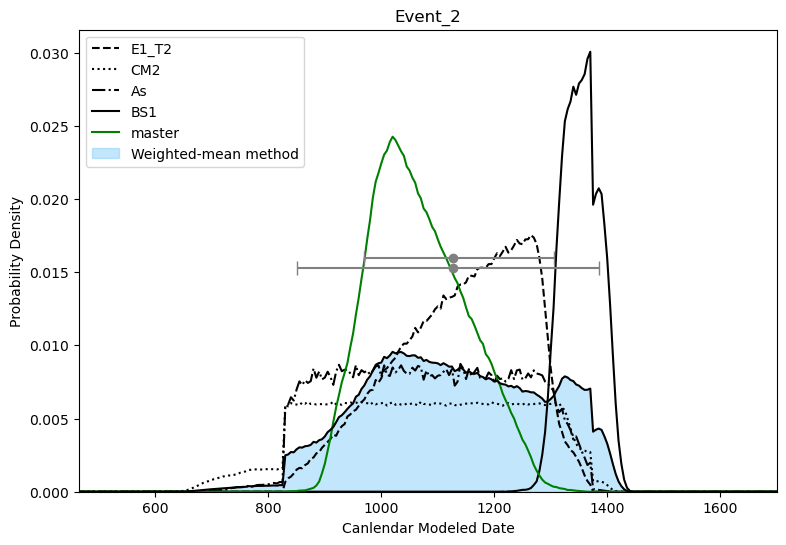

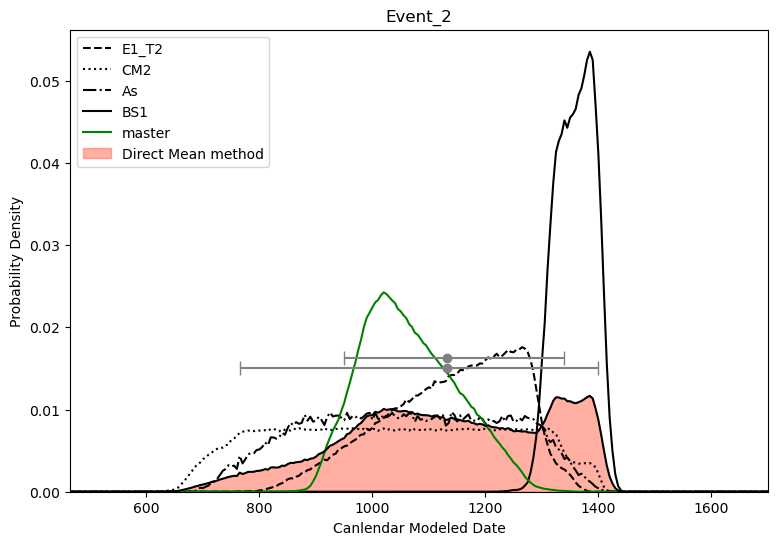

In [35]:
################################################
######### PLOTEAR THE COMBINED PDF #############
################################################

#styles = ['k--', 'k:', 'k-.', 'k-', 'r-', 'g-.','grey--']
styles = ['k--', 'k:', 'k-.', 'k-', 'g-', 'r-.']
lower_index3 = np.argmax(cdf_mean >= 0.025)
upper_index3 = np.argmax(cdf_mean >= 0.977)
lower_bound3 = time[lower_index3]
upper_bound3 = time[upper_index3]

plt.figure(2, figsize=(9,6))
  
for i, col in enumerate(PDFs_3):
    if col == 'w_mean':
        continue
    else:
        plt.plot(time, PDFs_3[col].values, styles[i], label = col)
        
plt.plot(time, PDFs_3['w_mean'], 'k')
plt.fill_between(time, 0, PDFs_3['w_mean'], alpha=0.5, color='lightskyblue', label='Weighted-mean method')
xerr = [[(-lower_bound+FPDF_mean)], [(-FPDF_mean+upper_bound)]]
plt.errorbar(FPDF_mean, 0.016, xerr=xerr, fmt='o', capsize=5, ecolor='gray', markerfacecolor='gray', markeredgecolor='gray', alpha=1)
xerr2 = [[(-lower_bound4+FPDF_mean)], [(-FPDF_mean+upper_bound4)]]
plt.errorbar(FPDF_mean, 0.0153, xerr=xerr2, fmt='o', capsize=5, ecolor='gray', markerfacecolor='gray', markeredgecolor='gray', alpha=1)
plt.xlim(lower_bound3 - 300, upper_bound3 + 300)
#plt.xlim(-6000, -3600)
plt.ylim(0)
plt.xlabel('Canlendar Modeled Date')
plt.ylabel('Probability Density')
plt.title(event)
plt.legend()

#SAVE DATA AND FIGURES HERE BELOW
# output = np.column_stack((time, PDFs_3['w_mean'].values)) # HERE TO EXTRACT RAW DATA OF THE COMBINED PDF (weigthed mean method)

# np.savetxt(
#     'event_2weighted.txt', # CHANGE the name of the output file according to the name of the event.
#     output,
#     fmt='%.6f',
#     delimiter='\t',
#     header='time\tweighted_PDF',
#     comments=''
# )
# plt.savefig(f"{event}weighted.pdf", bbox_inches='tight') # HERE TO EXTRACT THE FIGURE IN PDF format.


################################################
######## plot normal mean rupture method #######
################################################

plt.figure(3, figsize=(9,6))

for i, col in enumerate(PDFs_2):
    if col == 'mean':
        continue
    else:
        plt.plot(time, PDFs_2[col].values, styles[i], label = col)
        
if 'mean' in PDFs_2.columns:
    plt.plot(time, PDFs_2['mean'].values, 'k')
    
plt.fill_between(time, 0, PDFs_2['mean'].values, alpha=0.5, color='tomato', label='Direct Mean method')
xerr = [[(-lower_bound2+mean_r)], [(-mean_r+upper_bound2)]]
plt.errorbar(mean_r, 0.0163, xerr=xerr, fmt='o', capsize=5, ecolor='gray', markerfacecolor='gray', markeredgecolor='gray', alpha=1)
xerr3 = [[(-lower_bound5+mean_r)], [(-mean_r+upper_bound5)]]
plt.errorbar(mean_r, 0.015, xerr=xerr3, fmt='o', capsize=5, ecolor='gray', markerfacecolor='gray', markeredgecolor='gray', alpha=1)
plt.xlim(lower_bound3 - 300, upper_bound3 + 300)
plt.ylim(0)
plt.xlabel('Canlendar Modeled Date')
plt.ylabel('Probability Density')
plt.title(event)
plt.legend()

#SAVE DATA AND FIGURES HERE BELOW
# output = np.column_stack((time, PDFs_2['mean'].values)) # HERE TO EXTRACT RAW DATA OF THE COMBINED PDF (weigthed mean method)

# np.savetxt(
#     'event_2mean.txt', # CHANGE the name of the output file
#     output,
#     fmt='%.6f',
#     delimiter='\t',
#     header='time\tDirect_mean_PDF',
#     comments=''
# )
# plt.savefig(f"{event}mean.pdf", bbox_inches='tight') # HERE TO EXTRACT THE FIGURE IN PDF format.

